# PSR J0537-6910 — Modelo vs Datos Observacionales

Este notebook compara el modelo de rotación del púlsar (obtenido del archivo `.par`) con datos observacionales independientes (archivo `.dat`).

## Modelo teórico

La frecuencia de rotación se describe como expansión de Taylor:

$$F_0(t) = F_0 + F_1 t' + \frac{1}{2}F_2 t'^2 + \frac{1}{6}F_3 t'^3 + \sum_i \Delta F_{0,i}(t)$$

$$F_1(t) = F_1 + F_2 t' + \frac{1}{2}F_3 t'^2 + \sum_i \Delta F_{1,i}(t)$$

donde $t' = (t - \text{PEPOCH})$ en segundos y los términos $\Delta F_{0,i}$, $\Delta F_{1,i}$ son las contribuciones de cada glitch.

## Modelo de glitches

Cada glitch $i$ ocurre en la época $t_{g,i}$ (GLEP) y produce saltos permanentes en $F_0$ y $F_1$. Para $t > t_{g,i}$, su contribución es:

$$\Delta F_{0,i}(t) = \text{GLF0}_i + \text{GLF1}_i \cdot (t - t_{g,i}) + \frac{1}{2}\text{GLF2}_i \cdot (t - t_{g,i})^2$$

$$\Delta F_{1,i}(t) = \text{GLF1}_i + \text{GLF2}_i \cdot (t - t_{g,i})$$

Físicamente: un glitch es un aumento abrupto en $F_0$ (el púlsar gira de repente más rápido), seguido de una relajación gradual mediada por $\text{GLF1}_i < 0$ (frenado post-glitch más intenso).

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import re

# ── Configuración central del notebook ─────────────────────────────────────
CONFIG = {
    'PAR_FILE': 'nicer-paper.par',
    'DAT_FILE': 'min5-30vf-smth.dat',
    'USAR_GLITCHES': True,
    'GLITCHES_IGNORAR': [],
    'USAR_TRANSIENTES': False,  # requiere parámetros de recuperación
    'TRANSIENTES': {},          # formato: {idx_glitch: [{'dnu':..., 'tau_d':...}, ...]}
    'PLOT_INDIVIDUALES': False,
    'UMBRAL_CAMBIO_SIGMA': 5.0,
}

# Chequeo mínimo de configuración
if CONFIG['UMBRAL_CAMBIO_SIGMA'] <= 0:
    raise ValueError('UMBRAL_CAMBIO_SIGMA debe ser positivo.')

---
## 1. Lectura del archivo `.par`

Se extraen los parámetros de rotación base ($F_0, F_1, F_2, F_3$, PEPOCH) y los parámetros de cada glitch (GLEP, GLF0, GLF1, GLF2).

Se muestra además un resumen de parámetros y glitches detectados, con validación básica de campos faltantes.

In [29]:
def leer_par(filename):
    """
    Lee un archivo .par y retorna:
      - params: diccionario de parámetros globales
      - glitches: lista ordenada por índice de glitch
      - reporte: conteos de robustez del parsing
    """
    params = {}
    glitches_raw = {}
    reporte = {
        'lineas_leidas': 0,
        'lineas_validas': 0,
        'parametros_invalidos': 0,
        'glitches_incompletos': 0,
    }

    with open(filename, 'r', encoding='utf-8') as f:
        for line in f:
            reporte['lineas_leidas'] += 1
            line = re.sub(r'\\', '', line).strip()
            if not line or line.startswith('#'):
                continue

            parts = line.split()
            if len(parts) < 2:
                continue

            reporte['lineas_validas'] += 1
            key = parts[0]
            val_str = parts[1]

            m = re.match(r'(GLEP|GLPH|GLF0|GLF1|GLF2)_(\d+)', key)
            if m:
                gl_param = m.group(1)
                gl_idx = int(m.group(2))
                glitches_raw.setdefault(gl_idx, {})
                try:
                    glitches_raw[gl_idx][gl_param] = float(val_str)
                except ValueError:
                    reporte['parametros_invalidos'] += 1
                continue

            try:
                if ':' in val_str:
                    continue
                params[key] = float(val_str)
            except ValueError:
                reporte['parametros_invalidos'] += 1

    glitches = [glitches_raw[i] for i in sorted(glitches_raw)]

    # Reportar glitches sin época (GLEP) para trazabilidad
    for g in glitches:
        if 'GLEP' not in g:
            reporte['glitches_incompletos'] += 1

    params['glitches'] = glitches
    return params, reporte


params, reporte_par = leer_par(CONFIG['PAR_FILE'])

print('Púlsar: PSR J0537-6910')
print(f"  PEPOCH = {params.get('PEPOCH', np.nan)} MJD")
print(f"  F0     = {params.get('F0', np.nan):.12f} Hz")
print(f"  F1     = {params.get('F1', np.nan):.6e} Hz/s")
print(f"  F2     = {params.get('F2', 0.0):.6e} Hz/s²")
print(f"  F3     = {params.get('F3', 0.0):.6e} Hz/s³")

print(f"\nGlitches detectados: {len(params['glitches'])}")
for i, g in enumerate(params['glitches'], start=1):
    glep = g.get('GLEP')
    glep_str = f"{glep:.1f}" if glep is not None else '?'
    print(
        f"  Glitch {i}: GLEP={glep_str} MJD  "
        f"GLF0={g.get('GLF0', 0.0):.3e} Hz  "
        f"GLF1={g.get('GLF1', 0.0):.3e} Hz/s"
    )

print('\nSanity PAR:')
for k, v in reporte_par.items():
    print(f"  {k}: {v}")

Púlsar: PSR J0537-6910
  PEPOCH = 58020.0 MJD
  F0     = 61.924374260201 Hz
  F1     = -1.995469e-10 Hz/s
  F2     = 1.000000e-20 Hz/s²
  F3     = 0.000000e+00 Hz/s³

Glitches detectados: 8
  Glitch 1: GLEP=58083.0 MJD  GLF0=1.612e-05 Hz  GLF1=-1.500e-13 Hz/s
  Glitch 2: GLEP=58152.0 MJD  GLF0=3.603e-05 Hz  GLF1=-1.650e-13 Hz/s
  Glitch 3: GLEP=58363.0 MJD  GLF0=7.829e-06 Hz  GLF1=-2.288e-13 Hz/s
  Glitch 4: GLEP=58424.0 MJD  GLF0=2.533e-05 Hz  GLF1=-2.141e-13 Hz/s
  Glitch 5: GLEP=58566.0 MJD  GLF0=9.213e-06 Hz  GLF1=-9.520e-14 Hz/s
  Glitch 6: GLEP=58637.0 MJD  GLF0=2.699e-05 Hz  GLF1=-8.651e-14 Hz/s
  Glitch 7: GLEP=58807.0 MJD  GLF0=7.565e-06 Hz  GLF1=-2.213e-13 Hz/s
  Glitch 8: GLEP=58868.0 MJD  GLF0=2.404e-05 Hz  GLF1=-2.443e-13 Hz/s

Sanity PAR:
  lineas_leidas: 70
  lineas_validas: 70
  parametros_invalidos: 10
  glitches_incompletos: 0


---
## 2. Lectura del archivo `.dat`

El archivo `.dat` contiene mediciones observacionales con las columnas:

| Col | Descripción | Unidades originales | Factor de escala |
|-----|-------------|---------------------|------------------|
| 0   | MJD         | días                | —                |
| 1   | F0          | Hz                  | ×1               |
| 2   | err_F0      | Hz                  | ×1               |
| 3   | F1          | 1×10⁻¹⁵ Hz/s        | ×1×10⁻¹⁵         |
| 4   | err_F1      | 1×10⁻¹⁵ Hz/s        | ×1×10⁻¹⁵         |
| 5   | F2          | 1×10⁻²⁴ Hz/s²       | ×1×10⁻²⁴         |
| 6   | err_F2      | 1×10⁻²⁴ Hz/s²       | ×1×10⁻²⁴         |

In [30]:
def leer_dat(filename):
    """
    Lee el archivo .dat y retorna columnas en SI.
    Maneja filas corruptas y ordena temporalmente por MJD.
    """
    mjd, f0, err_f0, f1, err_f1, f2, err_f2 = [], [], [], [], [], [], []
    reporte = {
        'lineas_leidas': 0,
        'lineas_usadas': 0,
        'lineas_descartadas': 0,
    }

    with open(filename, 'r', encoding='utf-8') as fh:
        for line in fh:
            reporte['lineas_leidas'] += 1
            line = line.strip()
            if not line or line.startswith('#'):
                continue

            cols = line.split()
            if len(cols) < 5:
                reporte['lineas_descartadas'] += 1
                continue

            try:
                mjd.append(float(cols[0]))
                f0.append(float(cols[1]))
                err_f0.append(float(cols[2]))
                f1.append(float(cols[3]) * 1e-15)
                err_f1.append(float(cols[4]) * 1e-15)
                if len(cols) >= 7:
                    f2.append(float(cols[5]) * 1e-24)
                    err_f2.append(float(cols[6]) * 1e-24)
                else:
                    f2.append(np.nan)
                    err_f2.append(np.nan)
                reporte['lineas_usadas'] += 1
            except ValueError:
                reporte['lineas_descartadas'] += 1

    datos = {
        'mjd': np.asarray(mjd, dtype=float),
        'f0': np.asarray(f0, dtype=float),
        'err_f0': np.asarray(err_f0, dtype=float),
        'f1': np.asarray(f1, dtype=float),
        'err_f1': np.asarray(err_f1, dtype=float),
        'f2': np.asarray(f2, dtype=float),
        'err_f2': np.asarray(err_f2, dtype=float),
    }

    # Ordenar por MJD para evitar problemas si el archivo no viene ordenado
    order = np.argsort(datos['mjd'])
    for k in datos:
        datos[k] = datos[k][order]

    return datos, reporte


datos, reporte_dat = leer_dat(CONFIG['DAT_FILE'])

print(f"Puntos observacionales cargados: {len(datos['mjd'])}")
print(f"Rango temporal .dat: MJD {datos['mjd'].min():.1f} — {datos['mjd'].max():.1f}")

# Chequeo monotónico explícito post-ordenamiento
es_monotono = np.all(np.diff(datos['mjd']) >= 0)
print(f"MJD monotónico no-decreciente: {es_monotono}")

if len(params['glitches']) > 0 and all('GLEP' in g for g in params['glitches']):
    print(
        f"Rango temporal .par (glitches): "
        f"MJD {params['glitches'][0]['GLEP']:.0f} — {params['glitches'][-1]['GLEP']:.0f}"
    )
    glitches_en_rango = [
        g for g in params['glitches']
        if ('GLEP' in g) and (datos['mjd'].min() <= g['GLEP'] <= datos['mjd'].max())
    ]
else:
    print('Rango temporal .par (glitches): no definido (sin glitches válidos en .par)')
    glitches_en_rango = []

print('\nSanity DAT:')
for k, v in reporte_dat.items():
    print(f"  {k}: {v}")

print(f"\nGlitches del .par dentro del rango temporal del .dat: {len(glitches_en_rango)}")
if len(glitches_en_rango) == 0:
    print('  → Los glitches del .par ocurren después del período cubierto por el .dat.')
    print('  → En este rango, el modelo con y sin glitches puede coincidir.')

Puntos observacionales cargados: 329
Rango temporal .dat: MJD 51197.2 — 55926.9
MJD monotónico no-decreciente: True
Rango temporal .par (glitches): MJD 58083 — 58868

Sanity DAT:
  lineas_leidas: 329
  lineas_usadas: 329
  lineas_descartadas: 0

Glitches del .par dentro del rango temporal del .dat: 0
  → Los glitches del .par ocurren después del período cubierto por el .dat.
  → En este rango, el modelo con y sin glitches puede coincidir.


---
## 3. Modelo teórico con soporte de glitches

Se define `calcular_modelo(params, t_mjd_array, usar_glitches=True, glitches_ignorar=None)`, que evalúa $F_0(t)$ y $F_1(t)$ con expansión de Taylor y contribuciones de glitch solo para $t > GLEP$.

Aunque en este dataset los glitches del `.par` quedan fuera del rango temporal del `.dat`, la implementación queda lista para analizar datos post-glitch cuando existan.

In [31]:
def calcular_modelo(
    params,
    t_mjd_array,
    usar_glitches=True,
    glitches_ignorar=None,
    usar_transientes=False,
    transientes=None,
):
    """
    Evalúa F0(t) y F1(t) con expansión de Taylor y glitches.

    Componentes de glitch:
      - permanentes: GLF0, GLF1, GLF2
      - transientes opcionales: sum(dnu * exp(-dt/tau_d))
    """
    if glitches_ignorar is None:
        glitches_ignorar = []
    if transientes is None:
        transientes = {}

    F0 = params.get('F0', 0.0)
    F1 = params.get('F1', 0.0)
    F2 = params.get('F2', 0.0)
    F3 = params.get('F3', 0.0)
    PEPOCH = params.get('PEPOCH', 0.0)

    t = (np.asarray(t_mjd_array, dtype=float) - PEPOCH) * 86400.0

    f0_teo = F0 + F1 * t + 0.5 * F2 * t**2 + (1.0 / 6.0) * F3 * t**3
    f1_teo = F1 + F2 * t + 0.5 * F3 * t**2

    if usar_glitches:
        for idx, g in enumerate(params.get('glitches', []), start=1):
            if idx in glitches_ignorar:
                continue

            glep = g.get('GLEP')
            if glep is None:
                continue

            glf0 = g.get('GLF0', 0.0)
            glf1 = g.get('GLF1', 0.0)
            glf2 = g.get('GLF2', 0.0)

            t_g = (glep - PEPOCH) * 86400.0
            post = t > t_g
            dt = t[post] - t_g

            # Componente permanente
            f0_teo[post] += glf0 + glf1 * dt + 0.5 * glf2 * dt**2
            f1_teo[post] += glf1 + glf2 * dt

            # Componente transiente opcional
            if usar_transientes and idx in transientes:
                for term in transientes[idx]:
                    dnu = float(term.get('dnu', 0.0))
                    tau_d = float(term.get('tau_d', np.nan))
                    if not np.isfinite(tau_d) or tau_d <= 0:
                        continue
                    exp_term = dnu * np.exp(-dt / tau_d)
                    f0_teo[post] += exp_term
                    f1_teo[post] += -(dnu / tau_d) * np.exp(-dt / tau_d)

    return f0_teo, f1_teo


def calcular_metricas(y, yhat, sigma, n_params=1):
    """Métricas básicas y chi-cuadrado reducido."""
    resid = y - yhat
    rmse = np.sqrt(np.mean(resid**2))
    mae = np.mean(np.abs(resid))

    sigma_safe = np.where(np.asarray(sigma) > 0, sigma, np.nan)
    valid = np.isfinite(sigma_safe)
    dof = max(int(np.sum(valid)) - int(n_params), 1)
    chi2 = np.nansum((resid[valid] / sigma_safe[valid]) ** 2)
    chi_red = chi2 / dof

    return {
        'media_resid': float(np.mean(resid)),
        'std_resid': float(np.std(resid)),
        'rmse': float(rmse),
        'mae': float(mae),
        'chi_red': float(chi_red),
    }


def detectar_cambios(mjd, serie, sigma, umbral_sigma=5.0):
    """Detector simple de cambios abruptos entre muestras consecutivas."""
    dserie = np.diff(serie)
    sig = np.sqrt(np.maximum(sigma[:-1], 0.0) ** 2 + np.maximum(sigma[1:], 0.0) ** 2)
    sig = np.where(sig > 0, sig, np.nan)
    score = np.abs(dserie) / sig

    idx = np.where(score >= umbral_sigma)[0]
    candidatos = [
        {
            'mjd': float(mjd[i + 1]),
            'delta': float(dserie[i]),
            'score_sigma': float(score[i]),
        }
        for i in idx
    ]
    return candidatos

In [32]:
# ═══════════════════════════════════════════════════════════════════════════
# EVALUACIÓN DE MODELOS Y MÉTRICAS
#   A: sin glitches
#   B: glitches permanentes
#   C: glitches permanentes + transientes (opcional)
# ═══════════════════════════════════════════════════════════════════════════

# Modelo A
f0_sin, f1_sin = calcular_modelo(
    params,
    datos['mjd'],
    usar_glitches=False,
    glitches_ignorar=CONFIG['GLITCHES_IGNORAR'],
)

# Modelo B
f0_con, f1_con = calcular_modelo(
    params,
    datos['mjd'],
    usar_glitches=CONFIG['USAR_GLITCHES'],
    glitches_ignorar=CONFIG['GLITCHES_IGNORAR'],
    usar_transientes=False,
)

# Modelo C (si hay transientes)
f0_trans, f1_trans = calcular_modelo(
    params,
    datos['mjd'],
    usar_glitches=CONFIG['USAR_GLITCHES'],
    glitches_ignorar=CONFIG['GLITCHES_IGNORAR'],
    usar_transientes=CONFIG['USAR_TRANSIENTES'],
    transientes=CONFIG['TRANSIENTES'],
)

# Selección de referencia para plots/residuos
if CONFIG['USAR_TRANSIENTES']:
    f0_teo, f1_teo = f0_trans, f1_trans
    modelo_ref = 'C (con transientes)'
else:
    f0_teo, f1_teo = f0_con, f1_con
    modelo_ref = 'B (glitches permanentes)'

# Diferencias entre modelos

delta_f0 = f0_con - f0_sin
delta_f1 = f1_con - f1_sin

delta_f0_trans = f0_trans - f0_con
delta_f1_trans = f1_trans - f1_con

# Métricas de ajuste
mA_f0 = calcular_metricas(datos['f0'], f0_sin, datos['err_f0'], n_params=4)
mA_f1 = calcular_metricas(datos['f1'], f1_sin, datos['err_f1'], n_params=3)

mB_f0 = calcular_metricas(datos['f0'], f0_con, datos['err_f0'], n_params=4 + 3 * len(params.get('glitches', [])))
mB_f1 = calcular_metricas(datos['f1'], f1_con, datos['err_f1'], n_params=3 + 2 * len(params.get('glitches', [])))

mC_f0 = calcular_metricas(datos['f0'], f0_trans, datos['err_f0'], n_params=4 + 3 * len(params.get('glitches', [])))
mC_f1 = calcular_metricas(datos['f1'], f1_trans, datos['err_f1'], n_params=3 + 2 * len(params.get('glitches', [])))

print('═════════════════════════════════════════════════════════════')
print(f"Modelo de referencia para gráficos/residuos: {modelo_ref}")
print('')
print('A) Sin glitches')
print(f"  F0 -> χ²_red={mA_f0['chi_red']:.3e}, RMSE={mA_f0['rmse']:.3e}, MAE={mA_f0['mae']:.3e}")
print(f"  F1 -> χ²_red={mA_f1['chi_red']:.3e}, RMSE={mA_f1['rmse']:.3e}, MAE={mA_f1['mae']:.3e}")
print('B) Con glitches permanentes')
print(f"  F0 -> χ²_red={mB_f0['chi_red']:.3e}, RMSE={mB_f0['rmse']:.3e}, MAE={mB_f0['mae']:.3e}")
print(f"  F1 -> χ²_red={mB_f1['chi_red']:.3e}, RMSE={mB_f1['rmse']:.3e}, MAE={mB_f1['mae']:.3e}")
print('C) Con glitches + transientes')
print(f"  F0 -> χ²_red={mC_f0['chi_red']:.3e}, RMSE={mC_f0['rmse']:.3e}, MAE={mC_f0['mae']:.3e}")
print(f"  F1 -> χ²_red={mC_f1['chi_red']:.3e}, RMSE={mC_f1['rmse']:.3e}, MAE={mC_f1['mae']:.3e}")
print('')
print(f"ΔF0_B-A máx: {np.nanmax(np.abs(delta_f0)):.3e} Hz")
print(f"ΔF1_B-A máx: {np.nanmax(np.abs(delta_f1)):.3e} Hz/s")
print(f"ΔF0_C-B máx: {np.nanmax(np.abs(delta_f0_trans)):.3e} Hz")
print(f"ΔF1_C-B máx: {np.nanmax(np.abs(delta_f1_trans)):.3e} Hz/s")
print('═════════════════════════════════════════════════════════════')

# Glitches que efectivamente impactan el rango del .dat
glitches_en_rango = [
    g for g in params.get('glitches', [])
    if ('GLEP' in g) and (datos['mjd'].min() <= g['GLEP'] <= datos['mjd'].max())
]
print(f"Glitches del .par dentro del rango temporal del .dat: {len(glitches_en_rango)}")

═════════════════════════════════════════════════════════════
Modelo de referencia para gráficos/residuos: B (glitches permanentes)

A) Sin glitches
  F0 -> χ²_red=1.368e+12, RMSE=1.733e-03, MAE=1.592e-03
  F1 -> χ²_red=3.424e+07, RMSE=4.396e-12, MAE=4.209e-12
B) Con glitches permanentes
  F0 -> χ²_red=1.478e+12, RMSE=1.733e-03, MAE=1.592e-03
  F1 -> χ²_red=3.600e+07, RMSE=4.396e-12, MAE=4.209e-12
C) Con glitches + transientes
  F0 -> χ²_red=1.478e+12, RMSE=1.733e-03, MAE=1.592e-03
  F1 -> χ²_red=3.600e+07, RMSE=4.396e-12, MAE=4.209e-12

ΔF0_B-A máx: 0.000e+00 Hz
ΔF1_B-A máx: 0.000e+00 Hz/s
ΔF0_C-B máx: 0.000e+00 Hz
ΔF1_C-B máx: 0.000e+00 Hz/s
═════════════════════════════════════════════════════════════
Glitches del .par dentro del rango temporal del .dat: 0


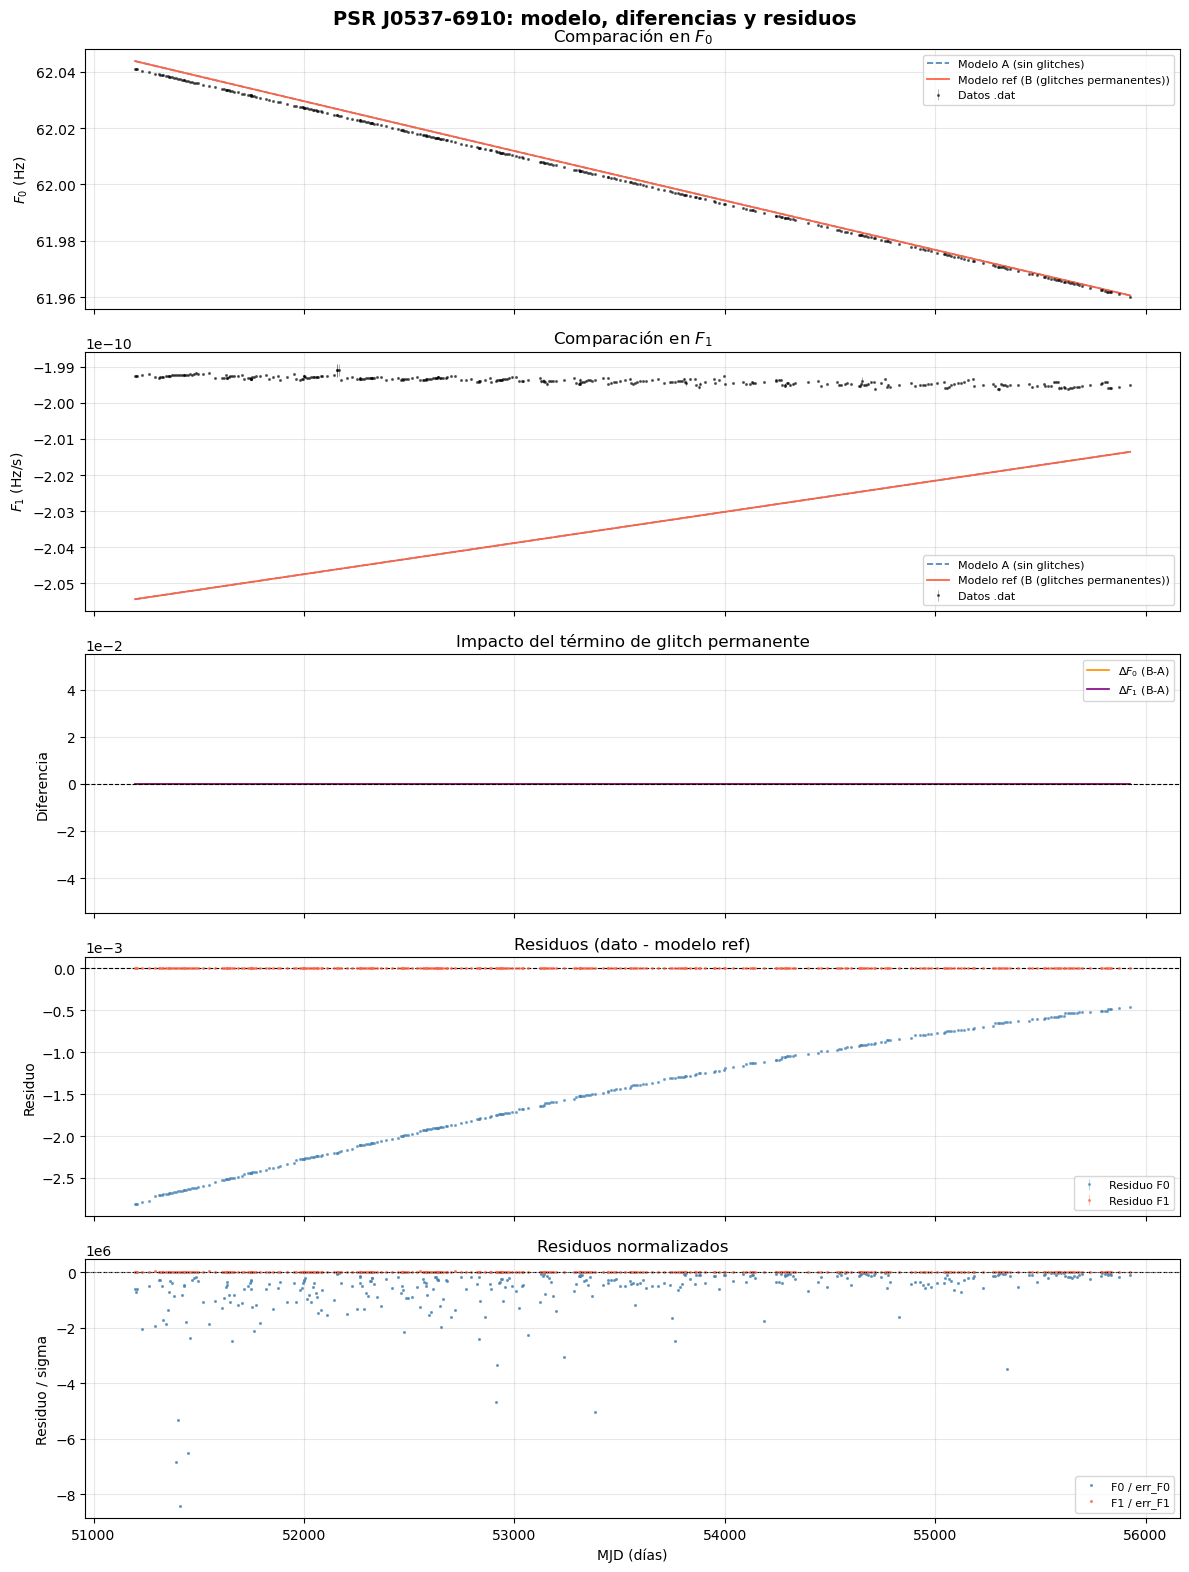

In [33]:
# ═══════════════════════════════════════════════════════════════════════════
# FIGURAS CONSOLIDADAS (sin redundancia)
# ═══════════════════════════════════════════════════════════════════════════

residuo_f0 = datos['f0'] - f0_teo
residuo_f1 = datos['f1'] - f1_teo
residuo_f0_norm = residuo_f0 / np.where(datos['err_f0'] > 0, datos['err_f0'], np.nan)
residuo_f1_norm = residuo_f1 / np.where(datos['err_f1'] > 0, datos['err_f1'], np.nan)

fig, axs = plt.subplots(5, 1, figsize=(12, 16), sharex=True)
fig.suptitle('PSR J0537-6910: modelo, diferencias y residuos', fontsize=14, fontweight='bold')

# Panel 1: F0
axs[0].plot(datos['mjd'], f0_sin, color='steelblue', linewidth=1.2, linestyle='--', label='Modelo A (sin glitches)')
axs[0].plot(datos['mjd'], f0_teo, color='tomato', linewidth=1.3, label=f'Modelo ref ({modelo_ref})')
axs[0].errorbar(datos['mjd'], datos['f0'], yerr=datos['err_f0'], fmt='.', color='black', markersize=2.5, elinewidth=0.4, alpha=0.5, label='Datos .dat')
axs[0].set_ylabel(r'$F_0$ (Hz)')
axs[0].set_title('Comparación en $F_0$')
axs[0].ticklabel_format(useOffset=False, style='plain', axis='y')
axs[0].grid(True, alpha=0.3)
axs[0].legend(fontsize=8)

# Panel 2: F1
axs[1].plot(datos['mjd'], f1_sin, color='steelblue', linewidth=1.2, linestyle='--', label='Modelo A (sin glitches)')
axs[1].plot(datos['mjd'], f1_teo, color='tomato', linewidth=1.3, label=f'Modelo ref ({modelo_ref})')
axs[1].errorbar(datos['mjd'], datos['f1'], yerr=datos['err_f1'], fmt='.', color='black', markersize=2.5, elinewidth=0.4, alpha=0.5, label='Datos .dat')
axs[1].set_ylabel(r'$F_1$ (Hz/s)')
axs[1].set_title('Comparación en $F_1$')
axs[1].ticklabel_format(useOffset=False, style='sci', scilimits=(0, 0), axis='y')
axs[1].grid(True, alpha=0.3)
axs[1].legend(fontsize=8)

# Panel 3: impacto de glitches permanentes
axs[2].plot(datos['mjd'], delta_f0, color='darkorange', linewidth=1.2, label=r'$\Delta F_0$ (B-A)')
axs[2].plot(datos['mjd'], delta_f1, color='purple', linewidth=1.2, label=r'$\Delta F_1$ (B-A)')
axs[2].axhline(0, color='black', linewidth=0.8, linestyle='--')
axs[2].set_ylabel('Diferencia')
axs[2].set_title('Impacto del término de glitch permanente')
axs[2].ticklabel_format(useOffset=False, style='sci', scilimits=(0, 0), axis='y')
axs[2].grid(True, alpha=0.3)
axs[2].legend(fontsize=8)

# Panel 4: residuos absolutos
axs[3].errorbar(datos['mjd'], residuo_f0, yerr=datos['err_f0'], fmt='.', color='steelblue', markersize=2.5, elinewidth=0.4, alpha=0.6, label='Residuo F0')
axs[3].errorbar(datos['mjd'], residuo_f1, yerr=datos['err_f1'], fmt='.', color='tomato', markersize=2.5, elinewidth=0.4, alpha=0.6, label='Residuo F1')
axs[3].axhline(0, color='black', linewidth=0.8, linestyle='--')
axs[3].set_ylabel('Residuo')
axs[3].set_title('Residuos (dato - modelo ref)')
axs[3].ticklabel_format(useOffset=False, style='sci', scilimits=(0, 0), axis='y')
axs[3].grid(True, alpha=0.3)
axs[3].legend(fontsize=8)

# Panel 5: residuos normalizados
axs[4].plot(datos['mjd'], residuo_f0_norm, '.', color='steelblue', markersize=2.5, alpha=0.7, label='F0 / err_F0')
axs[4].plot(datos['mjd'], residuo_f1_norm, '.', color='tomato', markersize=2.5, alpha=0.7, label='F1 / err_F1')
axs[4].axhline(0, color='black', linewidth=0.8, linestyle='--')
axs[4].axhline(3, color='gray', linewidth=0.6, linestyle=':')
axs[4].axhline(-3, color='gray', linewidth=0.6, linestyle=':')
axs[4].set_ylabel('Residuo / sigma')
axs[4].set_xlabel('MJD (días)')
axs[4].set_title('Residuos normalizados')
axs[4].grid(True, alpha=0.3)
axs[4].legend(fontsize=8)

for ax in axs:
    for g in params.get('glitches', []):
        ep = g.get('GLEP')
        if ep is not None and datos['mjd'].min() <= ep <= datos['mjd'].max():
            ax.axvline(ep, color='gray', linestyle=':', linewidth=0.8)

plt.tight_layout()
plt.show()

---
## 4. Comparación: F0 modelo vs datos

**Qué se espera ver:**
- La **curva teórica** (azul) representa el spin-down suave predicho por el `.par`.
- Los **puntos observacionales** (negro) incluyen el efecto de glitches históricos (no presentes en este `.par`), visibles como saltos abruptos hacia arriba seguidos de relajaciones hacia la tendencia de largo plazo.
- La **diferencia sistemática** entre curva y puntos refleja que el `.par` fue ajustado a datos NICER (~2017–2019) y el `.dat` cubre la era RXTE (~1999–2011): la extrapolación hacia atrás (aprox. ~7 a ~19 años según la fecha dentro del `.dat`) puede acumular desviaciones.

In [34]:
# Gráfico individual opcional (desactivado por defecto para evitar redundancia)
if CONFIG['PLOT_INDIVIDUALES']:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(datos['mjd'], f0_teo, color='steelblue', linewidth=1.5, label='Modelo ref')
    ax.errorbar(
        datos['mjd'], datos['f0'], yerr=datos['err_f0'], fmt='.', color='black',
        markersize=3, elinewidth=0.5, capsize=0, alpha=0.7, label='Datos (.dat)'
    )
    ax.set_xlabel('MJD (días)')
    ax.set_ylabel(r'$F_0$ (Hz)')
    ax.set_title('Comparación individual F0')
    ax.ticklabel_format(useOffset=False, style='plain', axis='y')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

---
## 5. Comparación: F1 modelo vs datos

**Qué se espera ver:**
- La **curva teórica** de $F_1$ es casi constante (el $F_2$ del `.par` es muy pequeño, $10^{-20}$ Hz/s²).
- Los **puntos observacionales** muestran saltos abruptos (más negativos) inmediatamente después de cada glitch histórico — el frenado post-glitch aumenta la tasa de desaceleración — seguidos de una recuperación gradual.
- Esta firma en $F_1$ es la evidencia directa de los **GLF1** (saltos negativos en la derivada de frecuencia) que caracterizan a los glitches.

In [35]:
# Gráfico individual opcional (desactivado por defecto para evitar redundancia)
if CONFIG['PLOT_INDIVIDUALES']:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(datos['mjd'], f1_teo, color='steelblue', linewidth=1.5, label='Modelo ref')
    ax.errorbar(
        datos['mjd'], datos['f1'], yerr=datos['err_f1'], fmt='.', color='black',
        markersize=3, elinewidth=0.5, capsize=0, alpha=0.7, label='Datos (.dat)'
    )
    ax.set_xlabel('MJD (días)')
    ax.set_ylabel(r'$F_1$ (Hz/s)')
    ax.set_title('Comparación individual F1')
    ax.ticklabel_format(useOffset=False, style='sci', scilimits=(0, 0), axis='y')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

---
## 6. Residuos: datos – modelo

Los residuos muestran la desviación sistemática entre las observaciones y el modelo teórico. Son útiles para identificar:
- **Tendencias de largo plazo**: indican que los parámetros del `.par` no describen perfectamente la época del `.dat`.
- **Saltos abruptos**: corresponden a glitches históricos no incluidos en este `.par`.

In [36]:
# ═══════════════════════════════════════════════════════════════════════════
# DIAGNÓSTICOS EXTRA: detección de cambios y segmentación temporal
# ═══════════════════════════════════════════════════════════════════════════

candidatos_f0 = detectar_cambios(
    datos['mjd'],
    datos['f0'],
    datos['err_f0'],
    umbral_sigma=CONFIG['UMBRAL_CAMBIO_SIGMA'],
)
candidatos_f1 = detectar_cambios(
    datos['mjd'],
    datos['f1'],
    datos['err_f1'],
    umbral_sigma=CONFIG['UMBRAL_CAMBIO_SIGMA'],
)

# Segmentación simple usando glitches conocidos dentro del rango
bordes = [datos['mjd'].min()]
for g in params.get('glitches', []):
    ep = g.get('GLEP')
    if ep is not None and datos['mjd'].min() < ep < datos['mjd'].max():
        bordes.append(ep)
bordes.append(datos['mjd'].max())
bordes = sorted(set(bordes))

print('═════════════════════════════════════════════════════════════')
print(f"Umbral detector cambios: {CONFIG['UMBRAL_CAMBIO_SIGMA']:.1f} sigma")
print(f"Candidatos de cambio en F0: {len(candidatos_f0)}")
print(f"Candidatos de cambio en F1: {len(candidatos_f1)}")

if candidatos_f0:
    print('\nPrimeros 5 candidatos F0:')
    for c in candidatos_f0[:5]:
        print(f"  MJD={c['mjd']:.2f}  delta={c['delta']:.3e}  score={c['score_sigma']:.2f}σ")

if candidatos_f1:
    print('\nPrimeros 5 candidatos F1:')
    for c in candidatos_f1[:5]:
        print(f"  MJD={c['mjd']:.2f}  delta={c['delta']:.3e}  score={c['score_sigma']:.2f}σ")

print('\nSegmentos temporales interglitch (MJD):')
for a, b in zip(bordes[:-1], bordes[1:]):
    print(f"  [{a:.2f}, {b:.2f}]  Δt={(b-a):.2f} días")

print('\nResumen residuos modelo de referencia:')
print(f"  F0 media={np.nanmean(residuo_f0):.4e} Hz | std={np.nanstd(residuo_f0):.4e} Hz")
print(f"  F1 media={np.nanmean(residuo_f1):.4e} Hz/s | std={np.nanstd(residuo_f1):.4e} Hz/s")
print('═════════════════════════════════════════════════════════════')

═════════════════════════════════════════════════════════════
Umbral detector cambios: 5.0 sigma
Candidatos de cambio en F0: 328
Candidatos de cambio en F1: 98

Primeros 5 candidatos F0:
  MJD=51203.46  delta=-1.086e-04  score=18134.62σ
  MJD=51204.72  delta=-2.172e-05  score=3632.00σ
  MJD=51232.21  delta=-4.732e-04  score=100644.75σ
  MJD=51262.69  delta=-5.247e-04  score=94655.73σ
  MJD=51294.14  delta=-4.991e-04  score=89967.08σ

Primeros 5 candidatos F1:
  MJD=51262.69  delta=2.843e-14  score=9.94σ
  MJD=51294.14  delta=-8.316e-14  score=48.38σ
  MJD=51412.85  delta=5.729e-15  score=5.32σ
  MJD=51546.69  delta=1.633e-14  score=5.82σ
  MJD=51576.62  delta=-1.358e-13  score=323.08σ

Segmentos temporales interglitch (MJD):
  [51197.15, 55926.92]  Δt=4729.77 días

Resumen residuos modelo de referencia:
  F0 media=-1.5916e-03 Hz | std=6.8501e-04 Hz
  F1 media=4.2087e-12 Hz/s | std=1.2688e-12 Hz/s
═════════════════════════════════════════════════════════════


---
## Notas sobre este conjunto de datos

**Por qué hay una desviación sistemática:**

El archivo `.par` (`nicer-paper.par`) fue ajustado a observaciones **NICER** del período 2017–2019 (PEPOCH = 58020 MJD). El archivo `.dat` contiene datos de la era **RXTE**, aproximadamente 1999–2011 (MJD ~51197–55926). La diferencia temporal implica una extrapolación hacia atrás de aproximadamente ~7 a ~19 años, según el tramo del `.dat` que se compare.

Adicionalmente, el `.dat` refleja la evolución del púlsar incluyendo **numerosos glitches históricos** que no están codificados en el `.par` (el cual solo documenta los 8 glitches de la era NICER). Cada uno de esos glitches históricos deja una huella visible como saltos abruptos en $F_0$ y $F_1$.

**Cómo activar/desactivar componentes del modelo:**

El control principal está centralizado en `CONFIG` al inicio del notebook:
```python
CONFIG['USAR_GLITCHES'] = True
CONFIG['GLITCHES_IGNORAR'] = [1, 3, 5]
CONFIG['USAR_TRANSIENTES'] = False
CONFIG['TRANSIENTES'] = {
    # 1: [{'dnu': 2e-7, 'tau_d': 20*86400.0}],
}
```
Esto permite comparar de forma consistente los modelos A (sin glitches), B (glitches permanentes) y C (glitches + transientes).